In [2]:
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEmbeddings, HuggingFaceEndpoint
from langchain_core.runnables import RunnableConfig
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
import os

load_dotenv()


True

In [3]:
llm = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-20b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
        streaming=True
)

model = ChatHuggingFace(llm=llm)


In [4]:
store = InMemoryStore()

user_id = "u1"

user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "My name is Roni"})
store.put(user_details, "profile_2", {"data": "I am a CSE student"})
store.put(user_details, "profile_3", {"data": "I love machine learning"})
store.put(user_details, "profile_4", {"data": "I am learning LangChain"})
store.put(user_details, "profile_5", {"data": "I like Python programming"})
store.put(user_details, "profile_6", {"data": "I am building AI projects"})

In [5]:
SYSTEM_PROMPT_TEMPLATE = """
You are a helpful AI assistant with long-term memory capabilities.

You have access to user-specific memories stored in a memory system. 
Whenever relevant, retrieve and use those memories to personalize responses.

Guidelines:
1. Use user-specific memory naturally in conversations.
2. Give concise and easy-to-understand answers.
3. Prefer simple wording and beginner-friendly explanations.
4. Use Python examples whenever possible.
5. Provide step-by-step guidance for technical topics.
6. Focus on being helpful, accurate, and personalized.
7. If no relevant memory exists, answer normally without mentioning memory retrieval.

The user's memory (which may be empty) is provided as : {user_details_content}
"""

In [11]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config['configurable']['user_id']
    user_details = ("user", user_id, "details")
    items = store.search(user_details)
    
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = "" #prompt say it may be empty

    SYSTEM_PROMPT = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content = user_details_content
    )

    system_msg = SystemMessage(content=SYSTEM_PROMPT)

    response = model.invoke([system_msg] + state["messages"])
    return {'messages': [response]}

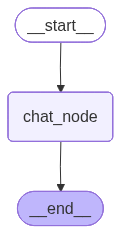

In [12]:
builder = StateGraph(MessagesState)

builder.add_node("chat_node", chat_node)
builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", END)

graph = builder.compile(store=store)
graph

In [13]:
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Expalin Machine Learning in simple Term."}]},
    config
)
print(result["messages"][-1].content)

**Machine Learning in a nutshell**

Imagine you have a robot that can learn to do something by looking at lots of examples instead of being told step‑by‑step.  
That’s what machine learning (ML) does: it lets a computer find patterns in data and then use those patterns to make predictions or decisions.

| Step | What happens | Example in Python |
|------|--------------|-------------------|
| 1. **Collect data** | Gather numbers, images, text, etc. | `X = np.array([[1, 2], [2, 1], [3, 3]])` |
| 2. **Choose a model** | Pick a mathematical “recipe” (e.g., linear regression, decision tree). | `model = LinearRegression()` |
| 3. **Train** | Show the model many examples and let it adjust its internal parameters. | `model.fit(X, y)` |
| 4. **Validate** | Test on new data to see how well it learned. | `pred = model.predict(new_X)` |
| 5. **Use** | Deploy the model in an app, robot, or web service. | `print(pred)` |

### Why it’s useful
- **Automation**: Tasks like spam filtering, image recogni

# CHATBOT CREATING NEW MEMORIES

In [33]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [34]:
store = InMemoryStore()

In [35]:
llm = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-20b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
        streaming=True
)

Extractor_llm = ChatHuggingFace(llm=llm)

In [25]:
class MemoryDecision(TypedDict):
    should_write: bool 
    memories: List[str] 

In [36]:
memory_extractor = Extractor_llm.with_structured_output(MemoryDecision)

In [37]:
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision["should_write"]:
        for mem in decision["memories"]:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

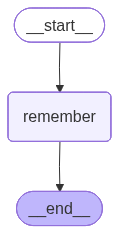

In [38]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [44]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is nitish"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [45]:
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [46]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)


Assistant: Noted.


In [47]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Nitish.
User teaches AI on YouTube.
User is a content creator focusing on AI education.
User's favorite programming language is Python.
User's name is Nitish
User teaches AI on YouTube
Favorite programming language is Python
